# Problem Çözme Becerileri Ölçeği (PÇBÖ) Analizi

**Ölçek:** Şahin, Şahin & Heppner (1993) — 35 madde, 3 alt boyut, 6'lı Likert  
**Desen:** Tek grup, ön test – son test  
**Analizler:** Güvenirlik (Cronbach α) → Normallik (Shapiro-Wilk) → Paired t-test + Cohen's d  
**Puanlama notu:** Düşük düzeltilmiş ortalama = daha iyi problem çözme becerisi (PSI orijinal yönü)

In [1]:
import sys
import warnings
warnings.filterwarnings('ignore')

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from problem_cozme_analiz import (
    analiz_calistir,
    FAKTÖR_ETIKET,
    FAKTÖRLER,
)

pd.set_option('display.max_colwidth', None)
pd.set_option('display.float_format', '{:.3f}'.format)

plt.rcParams.update({
    'font.family': 'DejaVu Sans',
    'axes.spines.top': False,
    'axes.spines.right': False,
    'figure.dpi': 120,
})

RENK_ON  = '#5B9BD5'
RENK_SON = '#ED7D31'

print('Kütüphaneler yüklendi.')

Kütüphaneler yüklendi.


## 1. Veri Yükleme ve Eşleştirme

In [2]:
s = analiz_calistir()

print('─' * 40)
print(f"Ön test katılımcı sayısı  : {s['n_ontest']}")
print(f"Son test katılımcı sayısı : {s['n_sontest']}")
print(f"Eşleşen (analiz) N        : {s['n_eslesen']}")
print('─' * 40)

on  = s['on_eslesen']
son = s['son_eslesen']

────────────────────────────────────────
Ön test katılımcı sayısı  : 48
Son test katılımcı sayısı : 47
Eşleşen (analiz) N        : 40
────────────────────────────────────────


## 2. Güvenirlik Analizi (Cronbach α)

In [3]:
guv = s['guvenirlik']
display(guv.style
    .set_caption('Tablo: Cronbach Alpha Güvenirlik Katsayıları')
    .format({'Cronbach α': '{:.3f}'})
    .hide(axis='index')
)

Alt Boyut,Madde Sayısı,Cronbach α
Problem Çözmeye Güvenme,11,0.840
Yaklaşma-Kaçınma Stili,16,0.833
Kişisel Kontrol,5,0.634
PÇBÖ Toplam,35,0.912


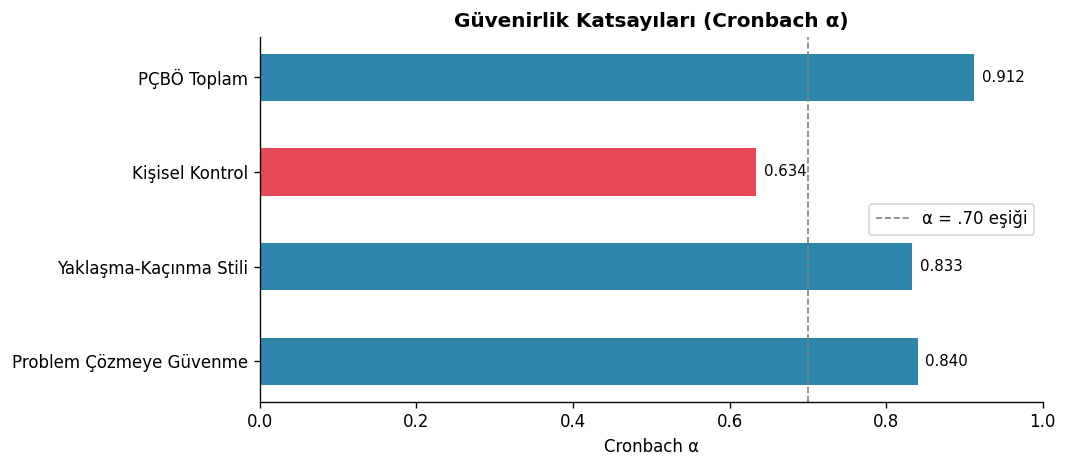

In [4]:
fig, ax = plt.subplots(figsize=(9, 4))

etiketler = guv['Alt Boyut'].tolist()
alfalar   = guv['Cronbach α'].tolist()
renkler   = ['#2E86AB' if a >= 0.70 else '#E84855' for a in alfalar]

bars = ax.barh(etiketler, alfalar, color=renkler, height=0.5)
ax.axvline(0.70, color='gray', linestyle='--', linewidth=1, label='α = .70 eşiği')
ax.set_xlim(0, 1)
ax.set_xlabel('Cronbach α')
ax.set_title('Güvenirlik Katsayıları (Cronbach α)', fontweight='bold')

for bar, val in zip(bars, alfalar):
    ax.text(val + 0.01, bar.get_y() + bar.get_height()/2,
            f'{val:.3f}', va='center', fontsize=9)

ax.legend()
plt.tight_layout()
plt.show()

## 3. Tanımlayıcı İstatistikler

In [5]:
tan = s['tanimlayici']
display(tan.style
    .set_caption('Tablo: Ön Test ve Son Test Tanımlayıcı İstatistikler (Düzeltilmiş Ortalama, 1–6 arası)')
    .hide(axis='index')
)

Ölçek / Alt Boyut,Ölçüm,N,Ortalama,SS,Min,Max
Problem Çözmeye Güvenme,Ön Test,40,2.659000,0.637000,1.450000,4.450000
Problem Çözmeye Güvenme,Son Test,40,2.386000,0.608000,1.550000,4.450000
Yaklaşma-Kaçınma Stili,Ön Test,40,3.033000,0.629000,1.750000,4.250000
Yaklaşma-Kaçınma Stili,Son Test,40,2.986000,0.613000,1.620000,4.060000
Kişisel Kontrol,Ön Test,40,2.815000,0.668000,1.400000,4.400000
Kişisel Kontrol,Son Test,40,2.525000,0.683000,1.200000,4.400000
PÇBÖ Toplam,Ön Test,40,2.904000,0.577000,1.830000,4.170000
PÇBÖ Toplam,Son Test,40,2.741000,0.520000,1.710000,3.940000


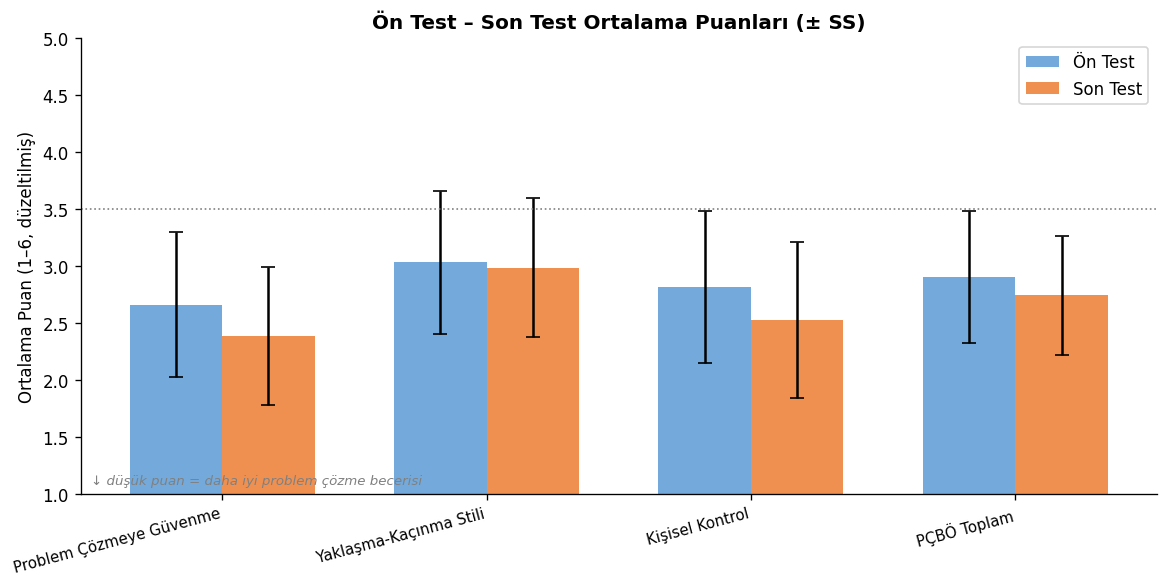

In [6]:
boyutlar  = list(FAKTÖRLER.keys()) + ['Toplam']
etiketler = [FAKTÖR_ETIKET[b] for b in boyutlar]

on_ort  = [on[b].mean()  for b in boyutlar]
son_ort = [son[b].mean() for b in boyutlar]
on_ss   = [on[b].std(ddof=1)  for b in boyutlar]
son_ss  = [son[b].std(ddof=1) for b in boyutlar]

x = np.arange(len(etiketler))
w = 0.35

fig, ax = plt.subplots(figsize=(10, 5))
b1 = ax.bar(x - w/2, on_ort,  w, yerr=on_ss,  capsize=4, color=RENK_ON,  label='Ön Test',  alpha=0.85)
b2 = ax.bar(x + w/2, son_ort, w, yerr=son_ss, capsize=4, color=RENK_SON, label='Son Test', alpha=0.85)

ax.set_xticks(x)
ax.set_xticklabels(etiketler, rotation=15, ha='right', fontsize=9)
ax.set_ylabel('Ortalama Puan (1–6, düzeltilmiş)')
ax.set_ylim(1, 5)
ax.set_title('Ön Test – Son Test Ortalama Puanları (± SS)', fontweight='bold')
ax.legend()
ax.axhline(3.5, color='gray', linestyle=':', linewidth=1)

# Not: düşük puan = iyi
ax.text(0.01, 0.02, '↓ düşük puan = daha iyi problem çözme becerisi',
        transform=ax.transAxes, fontsize=8, color='gray', style='italic')

plt.tight_layout()
plt.show()

## 4. Normallik Testi (Shapiro-Wilk)

In [7]:
norm = s['normallik']

def renk_normal(val):
    return 'color: green; font-weight: bold' if val == 'Evet' else 'color: red;'

display(norm.style
    .set_caption('Tablo: Shapiro-Wilk Normallik Testi Sonuçları')
    .map(renk_normal, subset=['Normal mi?'])
    .hide(axis='index')
)

Ölçek / Alt Boyut,Ölçüm,N,Shapiro-Wilk W,p,Normal mi?
Problem Çözmeye Güvenme,Ön Test,40,0.968000,0.305000,Evet
Problem Çözmeye Güvenme,Son Test,40,0.876000,0.000000,Hayır
Yaklaşma-Kaçınma Stili,Ön Test,40,0.982000,0.759000,Evet
Yaklaşma-Kaçınma Stili,Son Test,40,0.972000,0.418000,Evet
Kişisel Kontrol,Ön Test,40,0.980000,0.682000,Evet
Kişisel Kontrol,Son Test,40,0.977000,0.568000,Evet
PÇBÖ Toplam,Ön Test,40,0.973000,0.460000,Evet
PÇBÖ Toplam,Son Test,40,0.958000,0.138000,Evet


## 5. Bağımlı Örneklem t-Testi (Paired Samples t-Test)

In [8]:
tt = s['ttest']

def renk_anlamli(val):
    return 'color: green; font-weight: bold' if 'Evet' in str(val) else ''

display(tt.style
    .set_caption('Tablo: Bağımlı Örneklem t-Testi Sonuçları (t > 0 → azalış → gelişim)')
    .map(renk_anlamli, subset=['p < .05'])
    .hide(axis='index')
)

Ölçek / Alt Boyut,Ön x̄,Ön SS,Son x̄,Son SS,N,sd,t,p,p < .05,Cohen's d,Etki Büyüklüğü
Problem Çözmeye Güvenme,2.659000,0.637000,2.386000,0.608000,40,39,3.885000,0.000000,Evet*,0.614000,Orta
Yaklaşma-Kaçınma Stili,3.033000,0.629000,2.986000,0.613000,40,39,0.553000,0.584000,Hayır,0.087000,Çok küçük
Kişisel Kontrol,2.815000,0.668000,2.525000,0.683000,40,39,2.609000,0.013000,Evet*,0.412000,Küçük
PÇBÖ Toplam,2.904000,0.577000,2.741000,0.520000,40,39,2.372000,0.023000,Evet*,0.375000,Küçük


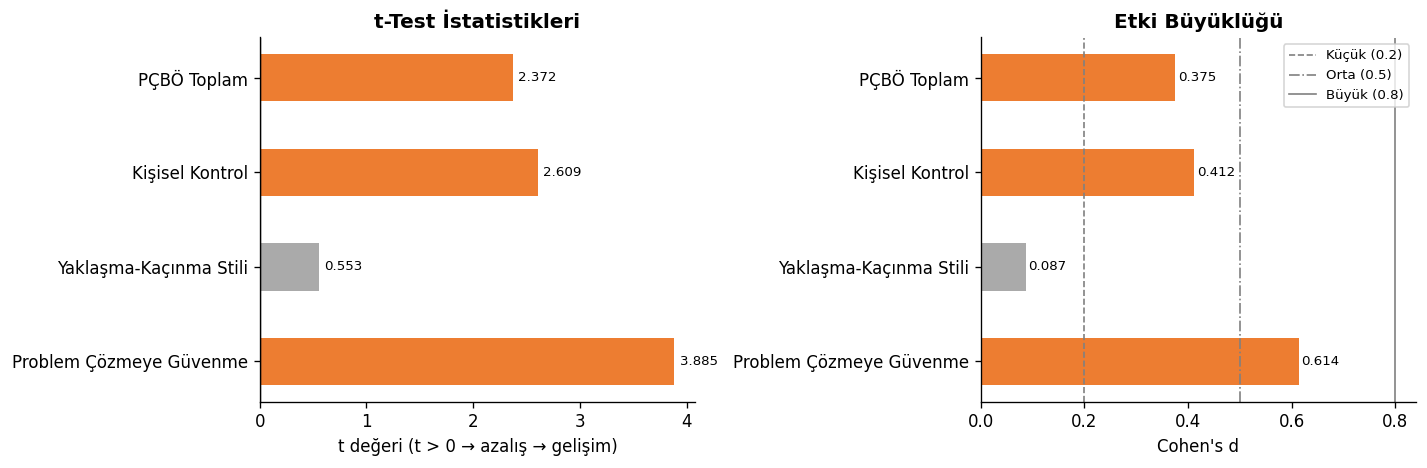

In [9]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

renkler_sig = [RENK_SON if p < 0.05 else '#AAAAAA' for p in tt['p']]

# Sol: t değerleri
axes[0].barh(tt['Ölçek / Alt Boyut'], tt['t'], color=renkler_sig, height=0.5)
axes[0].axvline(0, color='black', linewidth=0.8)
axes[0].set_xlabel('t değeri (t > 0 → azalış → gelişim)')
axes[0].set_title('t-Test İstatistikleri', fontweight='bold')

for i, (val, p) in enumerate(zip(tt['t'], tt['p'])):
    axes[0].text(val + 0.05, i, f'{val:.3f}', va='center', fontsize=8)

# Sağ: Cohen's d
axes[1].barh(tt['Ölçek / Alt Boyut'], tt["Cohen's d"], color=renkler_sig, height=0.5)
axes[1].axvline(0.2, color='gray', linestyle='--', linewidth=1, label='Küçük (0.2)')
axes[1].axvline(0.5, color='gray', linestyle='-.', linewidth=1, label='Orta (0.5)')
axes[1].axvline(0.8, color='gray', linestyle='-',  linewidth=1, label='Büyük (0.8)')
axes[1].set_xlabel("Cohen's d")
axes[1].set_title('Etki Büyüklüğü', fontweight='bold')
axes[1].legend(fontsize=8)

for i, val in enumerate(tt["Cohen's d"]):
    axes[1].text(val + 0.005, i, f'{val:.3f}', va='center', fontsize=8)

plt.tight_layout()
plt.show()

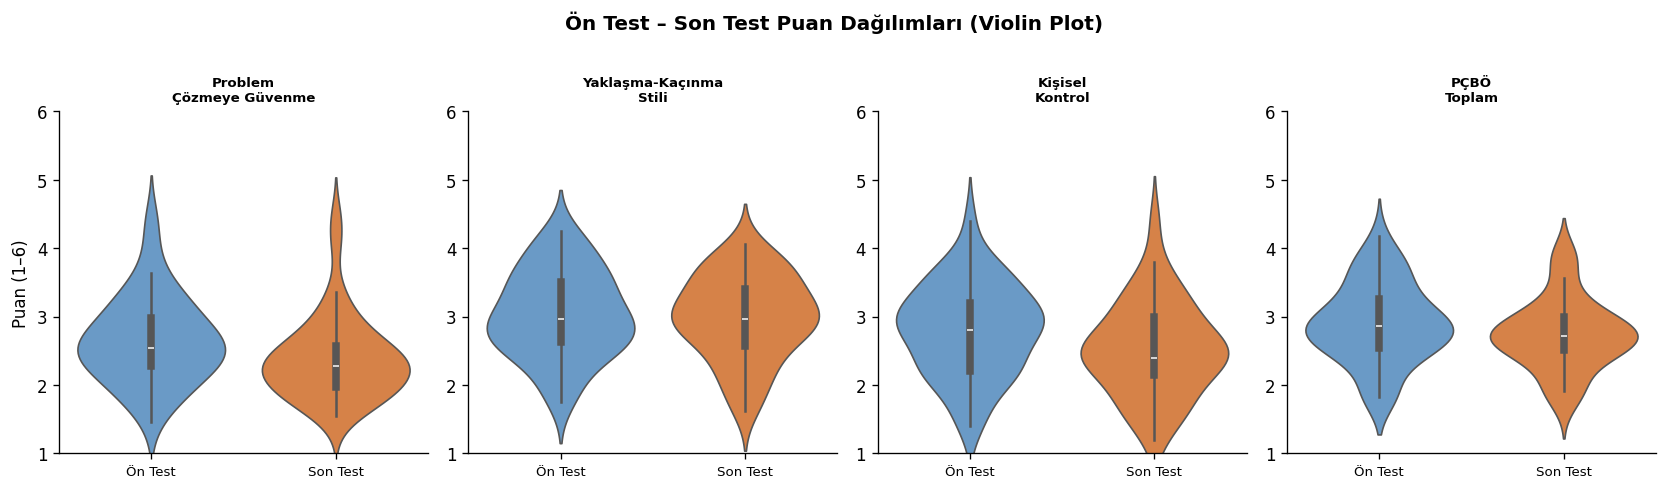

In [10]:
# Ön-Son Test dağılım karşılaştırması (violin + box)
boyutlar_goster = list(FAKTÖRLER.keys()) + ['Toplam']
fig, axes = plt.subplots(1, len(boyutlar_goster), figsize=(14, 4), sharey=False)

for ax, b in zip(axes, boyutlar_goster):
    veri = pd.DataFrame({
        'Puan': list(on[b]) + list(son[b]),
        'Test': ['Ön Test'] * len(on) + ['Son Test'] * len(son),
    })
    sns.violinplot(data=veri, x='Test', y='Puan', palette=[RENK_ON, RENK_SON],
                   inner='box', ax=ax, linewidth=1)
    ax.set_title(FAKTÖR_ETIKET[b].replace(' ', '\n', 1), fontsize=8, fontweight='bold')
    ax.set_xlabel('')
    ax.set_ylim(1, 6)
    ax.set_ylabel('Puan (1–6)' if b == boyutlar_goster[0] else '')
    ax.tick_params(axis='x', labelsize=8)

fig.suptitle('Ön Test – Son Test Puan Dağılımları (Violin Plot)', fontweight='bold', y=1.01)
plt.tight_layout()
plt.show()

## 6. Özet Yorum

In [11]:
print('=' * 65)
print('PÇBÖ ANALİZ ÖZET RAPORU')
print('=' * 65)
print(f"Eşleşen katılımcı sayısı (N): {s['n_eslesen']}")
alpha_top = s['guvenirlik'].iloc[-1]['Cronbach α']
print(f"Cronbach α (toplam, 35 madde): {alpha_top:.3f}")
print(f"Puanlama yönü: düşük ortalama = daha iyi problem çözme becerisi")
print()

for _, row in s['ttest'].iterrows():
    anlamli  = row['p'] < 0.05
    azaldi   = row["Son x̄"] < row["Ön x̄"]
    yon_etki = 'azalış (gelişim ✓)' if azaldi else 'artış (gerileme?)'
    cohens_d = row["Cohen's d"]
    etki     = row['Etki Büyüklüğü']
    t_val    = row['t']
    p_val    = row['p']
    sd_val   = row['sd']
    print(f"[{'✓' if anlamli else '–'}] {row['Ölçek / Alt Boyut']}")
    print(f"    Ön: x̄={row['Ön x̄']:.3f}  Son: x̄={row['Son x̄']:.3f}  → {yon_etki}")
    print(f"    t({sd_val})={t_val:.3f}, p={p_val:.3f}, d={cohens_d:.3f} ({etki})")
    durum = '✔ Anlamlı fark var (p < .05)' if anlamli else '✘ Anlamlı fark yok (p > .05)'
    print(f'    {durum}')
    print()

PÇBÖ ANALİZ ÖZET RAPORU
Eşleşen katılımcı sayısı (N): 40
Cronbach α (toplam, 35 madde): 0.912
Puanlama yönü: düşük ortalama = daha iyi problem çözme becerisi

[✓] Problem Çözmeye Güvenme
    Ön: x̄=2.659  Son: x̄=2.386  → azalış (gelişim ✓)
    t(39)=3.885, p=0.000, d=0.614 (Orta)
    ✔ Anlamlı fark var (p < .05)

[–] Yaklaşma-Kaçınma Stili
    Ön: x̄=3.033  Son: x̄=2.986  → azalış (gelişim ✓)
    t(39)=0.553, p=0.584, d=0.087 (Çok küçük)
    ✘ Anlamlı fark yok (p > .05)

[✓] Kişisel Kontrol
    Ön: x̄=2.815  Son: x̄=2.525  → azalış (gelişim ✓)
    t(39)=2.609, p=0.013, d=0.412 (Küçük)
    ✔ Anlamlı fark var (p < .05)

[✓] PÇBÖ Toplam
    Ön: x̄=2.904  Son: x̄=2.741  → azalış (gelişim ✓)
    t(39)=2.372, p=0.023, d=0.375 (Küçük)
    ✔ Anlamlı fark var (p < .05)

